<a href="https://colab.research.google.com/github/ScarrryMary/IT_MIPT_group25-26/blob/main/2_semester/Seminar2_10_25_26_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

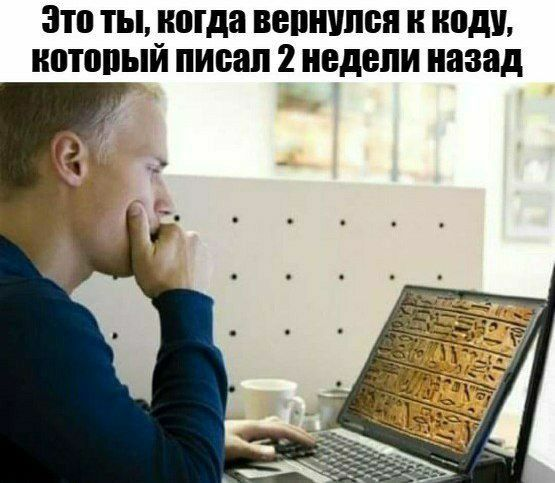

# Геометрия
Отрезок, для которого указано, какой из его концов считается началом, а какой концом, называется вектором. Вектор на плоскости можно задать двумя числами — его координатами по горизонтали и вертикали.

**Точка ≃ вектор**. Так как оба задаются просто парой чисел, можно считать их одним и тем же классом объектов и сопоставлять каждой точке её радиус-вектор — вектор из начала координат, ведущий в эту точку.



In [1]:
import math

class Vector:
    """Класс вектора (или точки) на плоскости."""

    def __init__(self, x=0, y=0):
        """Конструктор: создаёт вектор с координатами (x, y). По умолчанию (0,0)."""
        self.x = x
        self.y = y

    # ---------- Длина и угол ----------
    def length(self):
        """Возвращает длину вектора (евклидову норму)."""
        return math.hypot(self.x, self.y)  # эквивалент sqrt(x*x + y*y)

    def angle(self):
        """Возвращает угол вектора (в радианах) относительно оси X.
        Результат лежит в диапазоне [-π, +π]."""
        return math.atan2(self.y, self.x)

    # ---------- Повороты ----------
    def rotate(self, alpha):
        """Поворачивает вектор на угол alpha (в радианах) и возвращает новый вектор.
        Формула:
            x' = cos(alpha)*x - sin(alpha)*y
            y' = sin(alpha)*x + cos(alpha)*y
        """
        cos_a = math.cos(alpha)
        sin_a = math.sin(alpha)
        new_x = cos_a * self.x - sin_a * self.y
        new_y = sin_a * self.x + cos_a * self.y
        return Vector(new_x, new_y)

    def rotate_90(self):
        """Поворот на 90° против часовой стрелки: (x, y) -> (-y, x)."""
        return Vector(-self.y, self.x)

    # ---------- Перегрузка операторов ----------
    def __add__(self, other):
        """Сложение векторов."""
        return Vector(self.x + other.x, self.y + other.y)

    def __sub__(self, other):
        """Вычитание векторов."""
        return Vector(self.x - other.x, self.y - other.y)

    def __neg__(self):
        """Унарный минус: противоположный вектор."""
        return Vector(-self.x, -self.y)

    def __mul__(self, scalar):
        """Умножение на число (скаляр)."""
        return Vector(self.x * scalar, self.y * scalar)

    def __rmul__(self, scalar):
        """Умножение числа на вектор (симметричная версия)."""
        return self.__mul__(scalar)

    # ---------- Представление и ввод/вывод ----------
    def __str__(self):
        """Строковое представление для print()."""
        return f"{self.x} {self.y}"

    def __repr__(self):
        """Представление для отладки."""
        return f"Vector({self.x}, {self.y})"

    @staticmethod
    def from_input():
        """Считывает вектор из стандартного ввода (два числа через пробел)."""
        x, y = map(int, input().split())
        return Vector(x, y)


# ----- Пример использования -----
if __name__ == "__main__":
    # Создание векторов
    a = Vector(3, 4)
    b = Vector(1, 2)

    # Операции
    c = a + b
    print("a + b =", c)           # 4 6
    d = a - b
    print("a - b =", d)           # 2 2
    e = a.rotate_90()
    print("a повёрнутый на 90° =", e)   # -4 3

    # Длина и угол
    print("|a| =", a.length())    # 5.0
    print("угол a (рад) =", a.angle())

    # Ввод из консоли
    # print("Введите два целых числа для вектора:")
    # v = Vector.from_input()
    # print("Вы ввели:", v)

a + b = 4 6
a - b = 2 2
a повёрнутый на 90° = -4 3
|a| = 5.0
угол a (рад) = 0.9272952180016122


Помимо очевидных сложения, вычитания и умножения на константу, у векторов можно ввести и свои особенные операции, которые нам упростят жизнь.



**Скалярное произведение** (англ. dot product) двух векторов равно произведению их длин и косинуса угла между ними. Для него справедлива следующая формула:

$a⋅b=∣a∣⋅∣b∣⋅cosθ=x_a x_b + y_a y_b$  

Геометрически, она равна проекции вектора $b$ на вектор $a$, помноженный на длину $а$:




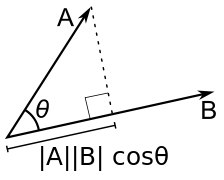

Полезные свойства:

* Скалярное произведение симметрично ($a⋅b=b⋅a$).
* Перпендикулярные вектора должны иметь нулевое скалярное произведение.
* Если угол острый, то скалярное произведение положительное.
* Если угол тупой, то скалярное произведение отрицательное.


**Векторное произведение** (англ. cross product, также называется косым или псевдоскалярным) для двух векторов равно произведению их длин и синуса угла между ними — причём знак этого синуса зависит от порядка операндов. Оно тоже удобно выражается в координатах:

$a×b=∣a∣⋅∣b∣⋅sinθ=x_a y_b − y_a x_b$  
​
Геометрически, это ориентированная площадь параллелограмма, натянутого на вектора $a$ и $b$.

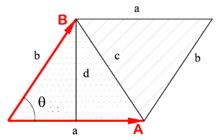

Его свойства:

* Векторное произведение антисимметрично: $a×b=−(b×a)$.
* Коллинеарные вектора имеют нулевое векторное произведение.
* Если $b$ «слева» от $a$, то векторное произведение положительное.
* Если $b$ «справа» от $a$, то векторное произведение отрицательное.


**Примечание**. Вообще говоря, формально векторное произведение определяется не так. Оно определено как вектор такой же длины, но перпендикулярный обоим исходным векторам. Это имеет применение в трёхмерной геометрии и физике, но пока в нашем двумерном мире об этом думать не надо.

In [2]:
import math

class Vector:
    def __init__(self, x=0, y=0):
        self.x = x
        self.y = y

    # --- Длина и угол ---
    def length(self):
        return math.hypot(self.x, self.y)

    def angle(self):
        return math.atan2(self.y, self.x)

    # --- Скалярное произведение ---
    def dot(self, other):
        """Скалярное произведение (a·b) = x1*x2 + y1*y2."""
        return self.x * other.x + self.y * other.y

    # Перегрузка оператора @ для скалярного произведения
    def __matmul__(self, other):
        return self.dot(other)

    # --- Векторное произведение (псевдоскаляр) ---
    def cross(self, other):
        """Векторное произведение (a×b) = x1*y2 - y1*x2.
        Положительное, если b слева от a."""
        return self.x * other.y - self.y * other.x

    # --- Угол между двумя векторами ---
    def angle_between(self, other):
        """Угол (в радианах) от self до other.
        Использует atan2(cross, dot), возвращает значение в [-π, π]."""
        return math.atan2(self.cross(other), self.dot(other))

    # --- Остальные методы (+, -, *, rotate, и т.д.) ---
    def __add__(self, other):
        return Vector(self.x + other.x, self.y + other.y)

    def __sub__(self, other):
        return Vector(self.x - other.x, self.y - other.y)

    def __neg__(self):
        return Vector(-self.x, -self.y)

    def __mul__(self, scalar):
        """Умножение вектора на число."""
        return Vector(self.x * scalar, self.y * scalar)

    def __rmul__(self, scalar):
        return self.__mul__(scalar)

    def rotate(self, alpha):
        cos_a = math.cos(alpha)
        sin_a = math.sin(alpha)
        return Vector(
            cos_a * self.x - sin_a * self.y,
            sin_a * self.x + cos_a * self.y
        )

    def rotate_90(self):
        return Vector(-self.y, self.x)

    def __str__(self):
        return f"{self.x} {self.y}"

    def __repr__(self):
        return f"Vector({self.x}, {self.y})"

    @staticmethod
    def from_input():
        x, y = map(int, input().split())
        return Vector(x, y)


# --- Свободная функция для угла ---
def angle_between(a: Vector, b: Vector) -> float:
    """Угол между векторами a и b (в радианах)."""
    return math.atan2(a.cross(b), a.dot(b))

if __name__ == "__main__":
    a = Vector(3, 4)
    b = Vector(1, 2)

    print("Скалярное произведение (через метод):", a.dot(b))        # 3*1 + 4*2 = 11
    print("Скалярное произведение (через @):", a @ b)               # 11
    print("Векторное произведение (через cross):", a.cross(b))      # 3*2 - 4*1 = 2
    print("Угол между a и b (рад):", a.angle_between(b))
    print("Угол между a и b (функция):", angle_between(a, b))

    # Проверка свойств из статьи:
    c = Vector(2, 2)
    d = Vector(-2, 2)
    print("Перпендикулярны? (dot = 0):", c.dot(d))                  # 2*(-2) + 2*2 = 0 -> да
    print("Векторное произведение (знак):", a.cross(b))             # 2 > 0 -> b слева от a

Скалярное произведение (через метод): 11
Скалярное произведение (через @): 11
Векторное произведение (через cross): 2
Угол между a и b (рад): 0.17985349979247828
Угол между a и b (функция): 0.17985349979247828
Перпендикулярны? (dot = 0): 0
Векторное произведение (знак): 2


Скалярное и векторное произведения тесно связаны с углами между векторами и могут использоваться для подсчета величин вроде ориентированных углов и площадей, которые обычно используются для разных проверок.

В дальнейшем, свойства произведений помогут нам в определении взаимного расположения точек и, например, прямой, поэтому важно эти свойства понять и крепко запомнить.

### Прямые и отрезки

В вычислительной геометрии часто требуется уметь определять взаимное положение геометрических объектов. Например, проверять, пересекаются ли отрезки. В этом нам поможет скалярное и векторное произведение, а также небольшой разбор случаев:

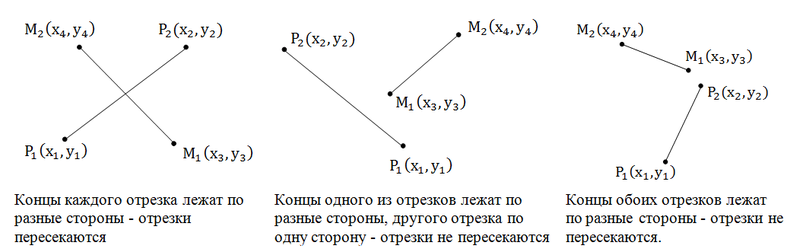

В терминах произведений, «концы отрезка лежат по разные стороны относительно другого отрезка», например, записывается как:

$[(M_1− P_1)×(P_2 − P_1)]⋅[(M_2 − P_1)×(P_2 − P_1)] < 0$

### Лучи и прямые
Луч — это отрезок, бесконечный в одном из направлений. Его можно хранить как точку и либо явный вектор направления, либо любую другую его точку.

С прямыми дела обстоят немного сложнее. Здесь есть целых 4 имеющих право на жизнь способа их хранить:

1. Нормальным уравнением: $A⋅x+B⋅y+C=0$.
2. Двумя точками.
3. Точкой и направляющим вектором (любым): $r = at+b$.
4. Точкой и нормальным вектором (любым).

Также их иногда удобно хранить уравнением $y=kx+b$, как в школе, однако для вертикальных прямых придётся делать отдельный костыль.

Часто во входе прямые заданы в одном виде, но удобнее работать с другим. Реализуются основные переходы так:

* 2→1: достаточно найти любое решение системы из 2 уравнений и 3 неизвестных.
* 1→3: если прямая задаётся уравнением, то вектор $(−B;A)$ — направляющий к прямой (важно помнить, что у прямой есть два «направления»).
* 1→4: если прямая задаётся уравнением, то вектор $(A;B)$ — нормальный к прямой (важно помнить, что упрямой есть 2 «направления нормали»).
* 4, 3→1: нужно решить систему из 1 уравнения и 1 неизвестного, раз уж из предыдущих пунктов мы уже знаем подходящие $A$ и $B$.
* 1→2: достаточно выбрать любые две точки на прямой — например:

In [ ]:
import math

# ========== Вектор (он же точка) ==========
class Vector:
    def __init__(self, x=0, y=0):
        self.x = x
        self.y = y

    def __add__(self, other):
        return Vector(self.x + other.x, self.y + other.y)

    def __sub__(self, other):
        return Vector(self.x - other.x, self.y - other.y)

    def __neg__(self):
        return Vector(-self.x, -self.y)

    def __mul__(self, scalar):
        return Vector(self.x * scalar, self.y * scalar)

    def __rmul__(self, scalar):
        return self.__mul__(scalar)

    def dot(self, other):
        return self.x * other.x + self.y * other.y

    def cross(self, other):
        return self.x * other.y - self.y * other.x

    def length(self):
        return math.hypot(self.x, self.y)

    def __str__(self):
        return f"({self.x}, {self.y})"

    def __repr__(self):
        return f"Vector({self.x}, {self.y})"


# ========== Отрезок ==========
class Segment:
    def __init__(self, p: Vector, q: Vector):
        self.p = p
        self.q = q

    @staticmethod
    def _orientation(a: Vector, b: Vector, c: Vector) -> int:
        """Знак ориентированной площади треугольника ABC.
        Возвращает: >0 - против часовой, <0 - по часовой, 0 - коллинеарны."""
        return (b - a).cross(c - a)

    def _on_segment(self, a: Vector, b: Vector, c: Vector) -> bool:
        """Проверка, лежит ли точка c на отрезке ab (включая концы)."""
        # Коллинеарность и проекция на bounding box
        if self._orientation(a, b, c) != 0:
            return False
        return (min(a.x, b.x) <= c.x <= max(a.x, b.x) and
                min(a.y, b.y) <= c.y <= max(a.y, b.y))

    def intersects(self, other: 'Segment') -> bool:
        """Проверка пересечения двух отрезков (включая концы)."""
        p1, q1 = self.p, self.q
        p2, q2 = other.p, other.q

        o1 = self._orientation(p1, q1, p2)
        o2 = self._orientation(p1, q1, q2)
        o3 = self._orientation(p2, q2, p1)
        o4 = self._orientation(p2, q2, q1)

        # Общий случай: концы лежат по разные стороны от обоих отрезков
        if o1 * o2 < 0 and o3 * o4 < 0:
            return True

        # Специальные случаи (точка на конце или отрезок вырожден)
        if o1 == 0 and self._on_segment(p1, q1, p2): return True
        if o2 == 0 and self._on_segment(p1, q1, q2): return True
        if o3 == 0 and self._on_segment(p2, q2, p1): return True
        if o4 == 0 and self._on_segment(p2, q2, q1): return True
        return False


# ========== Прямая ==========
class Line:
    """Прямая, заданная уравнением Ax + By + C = 0 (нормаль (A, B), не обнулена)."""
    def __init__(self, A: float, B: float, C: float):
        self.A = A
        self.B = B
        self.C = C

    @classmethod
    def from_two_points(cls, p: Vector, q: Vector):
        """Прямая через две точки. Направляющий вектор (q-p)."""
        A = p.y - q.y
        B = q.x - p.x
        C = p.x * q.y - q.x * p.y
        return cls(A, B, C)

    @classmethod
    def from_point_and_direction(cls, point: Vector, direction: Vector):
        """Прямая: point + t * direction. Не вертикальная? не важно."""
        # Нормаль перпендикулярна направлению: (direction.y, -direction.x)
        A = direction.y
        B = -direction.x
        C = -(A * point.x + B * point.y)
        return cls(A, B, C)

    @classmethod
    def from_point_and_normal(cls, point: Vector, normal: Vector):
        """Прямая с заданным нормальным вектором."""
        A, B = normal.x, normal.y
        C = -(A * point.x + B * point.y)
        return cls(A, B, C)

    def normal(self) -> Vector:
        """Вектор нормали (A, B)."""
        return Vector(self.A, self.B)

    def direction(self) -> Vector:
        """Направляющий вектор прямой (перпендикулярен нормали)."""
        return Vector(-self.B, self.A)

    def distance_to_point(self, point: Vector) -> float:
        """Расстояние от точки до прямой по формуле |Ax0+By0+C| / sqrt(A^2+B^2)."""
        return abs(self.A * point.x + self.B * point.y + self.C) / math.hypot(self.A, self.B)

    def projection(self, point: Vector) -> Vector:
        """Проекция точки на прямую."""
        # Нормируем нормаль и сдвигаем точку вдоль неё
        norm = self.normal()
        len_norm = norm.length()
        if len_norm == 0:
            return point  # вырожденный случай
        # Знак: подставляем точку в уравнение прямой, чтобы определить направление
        val = self.A * point.x + self.B * point.y + self.C
        # Вектор от точки до прямой: - (val / len_norm) * (norm / len_norm)
        # Тогда проекция = point + correction
        correction = - (val / (len_norm * len_norm)) * norm
        return point + correction

    def reflection(self, point: Vector) -> Vector:
        """Отражение точки относительно прямой."""
        proj = self.projection(point)
        # Отражённая точка: point + 2*(proj - point)
        return point + 2 * (proj - point)

    def intersection(self, other: 'Line') -> Vector or None:
        """Точка пересечения двух прямых. Если параллельны — вернёт None."""
        det = self.A * other.B - other.A * self.B
        if abs(det) < 1e-12:          # параллельны или совпадают
            return None
        x = (self.B * other.C - other.B * self.C) / det
        y = (other.A * self.C - self.A * other.C) / det
        return Vector(x, y)


# ========== Дополнительные функции (как в статье) ==========
def distance_point_to_line_by_vectors(point: Vector, a: Vector, b: Vector) -> float:
    """Расстояние от точки до прямой, заданной двумя точками a и b."""
    # Используем формулу: |PA × PB| / |AB|
    return abs((a - point).cross(b - point)) / (a - b).length()

def projection_point_to_line_by_vectors(point: Vector, base: Vector, direction: Vector) -> Vector:
    """Проекция точки на прямую (base + t*direction). Формула из C++ кода статьи."""
    # Переносим всё в начало координат base
    vec = point - base
    # Коэффициент t = (vec·direction) / (direction·direction)
    t = vec.dot(direction) / direction.dot(direction)
    return base + t * direction

def reflect_point_over_line_by_vectors(point: Vector, base: Vector, direction: Vector) -> Vector:
    """Отражение точки относительно прямой (base + t*direction)."""
    proj = projection_point_to_line_by_vectors(point, base, direction)
    return point + 2 * (proj - point)


# ========== Примеры использования ==========
if __name__ == "__main__":
    # Отрезки
    seg1 = Segment(Vector(0, 0), Vector(2, 2))
    seg2 = Segment(Vector(0, 2), Vector(2, 0))
    print("Отрезки пересекаются?", seg1.intersects(seg2))  # True

    # Прямая через точки (1,0) и (0,1)
    line = Line.from_two_points(Vector(1, 0), Vector(0, 1))
    pt = Vector(2, 3)
    print("Расстояние от (2,3) до прямой x+y-1=0:", line.distance_to_point(pt))
    print("Проекция (2,3):", line.projection(pt))
    print("Отражение (2,3):", line.reflection(pt))

    # Пересечение двух прямых
    line1 = Line.from_two_points(Vector(0, 0), Vector(1, 1))   # y = x
    line2 = Line.from_two_points(Vector(1, 0), Vector(0, 1))   # x + y = 1
    inter = line1.intersection(line2)
    print("Пересечение y=x и x+y=1:", inter)

    # Функции с векторами (проекция на прямую, заданную точкой и направлением)
    base = Vector(1, 0)
    dir_vec = Vector(0, 1)   # вертикальная прямая x=1
    point = Vector(3, 5)
    proj = projection_point_to_line_by_vectors(point, base, dir_vec)
    print("Проекция (3,5) на x=1:", proj)          # (1,5)
    reflect = reflect_point_over_line_by_vectors(point, base, dir_vec)
    print("Отражение (3,5) относительно x=1:", reflect)  # (-1,5)

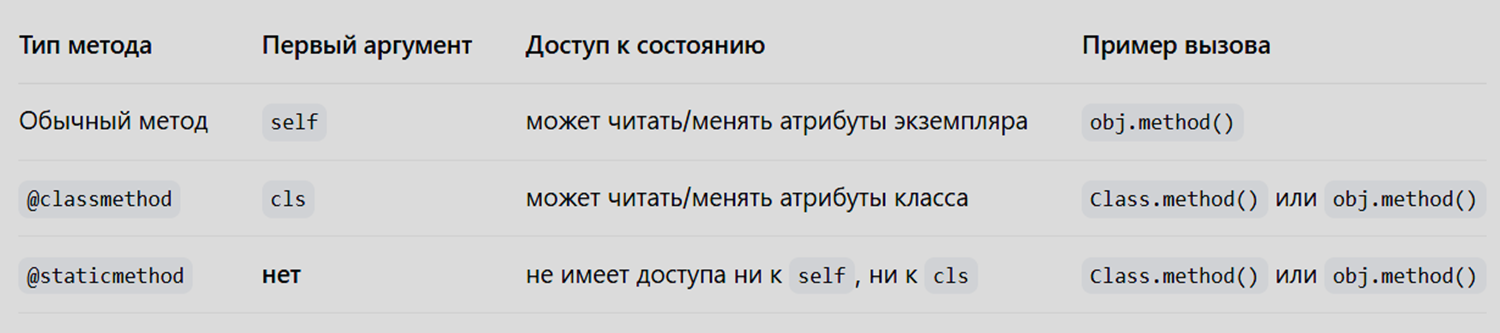

Для способов 2-4 все проверки почти такие же, как для отрезков. На самом деле, в геометрических задачах часто можно ввести «bounding box» — квадрат с очень далекими границами, все точки за пределами которого считаются «бесконечностью». Тогда бесконечные прямые и лучи можно заменить на отрезки, упирающиеся в эти бесконечные границы, и делать все проверки как с обычными отрезками.

В случае прямых, заданных формулой, всё совсем по-другому.

### Расстояние от точки до прямой

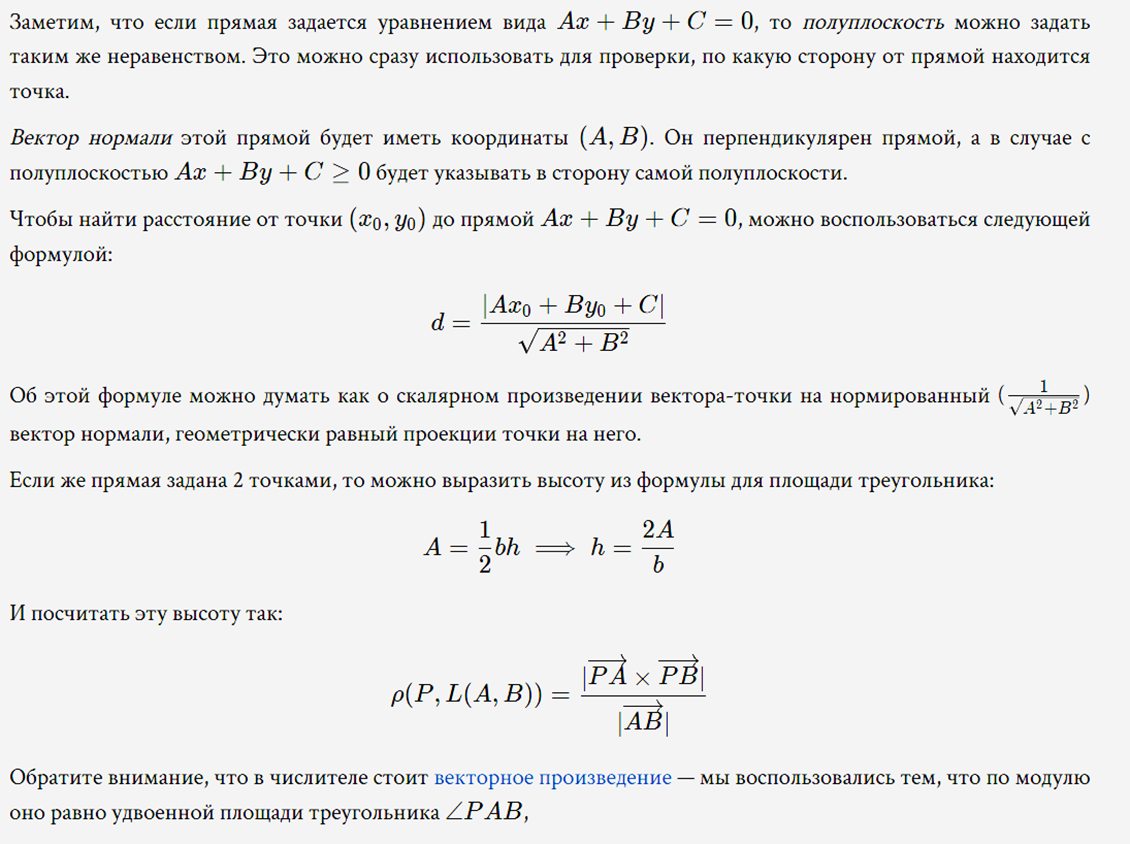

### Точка пересечения прямых

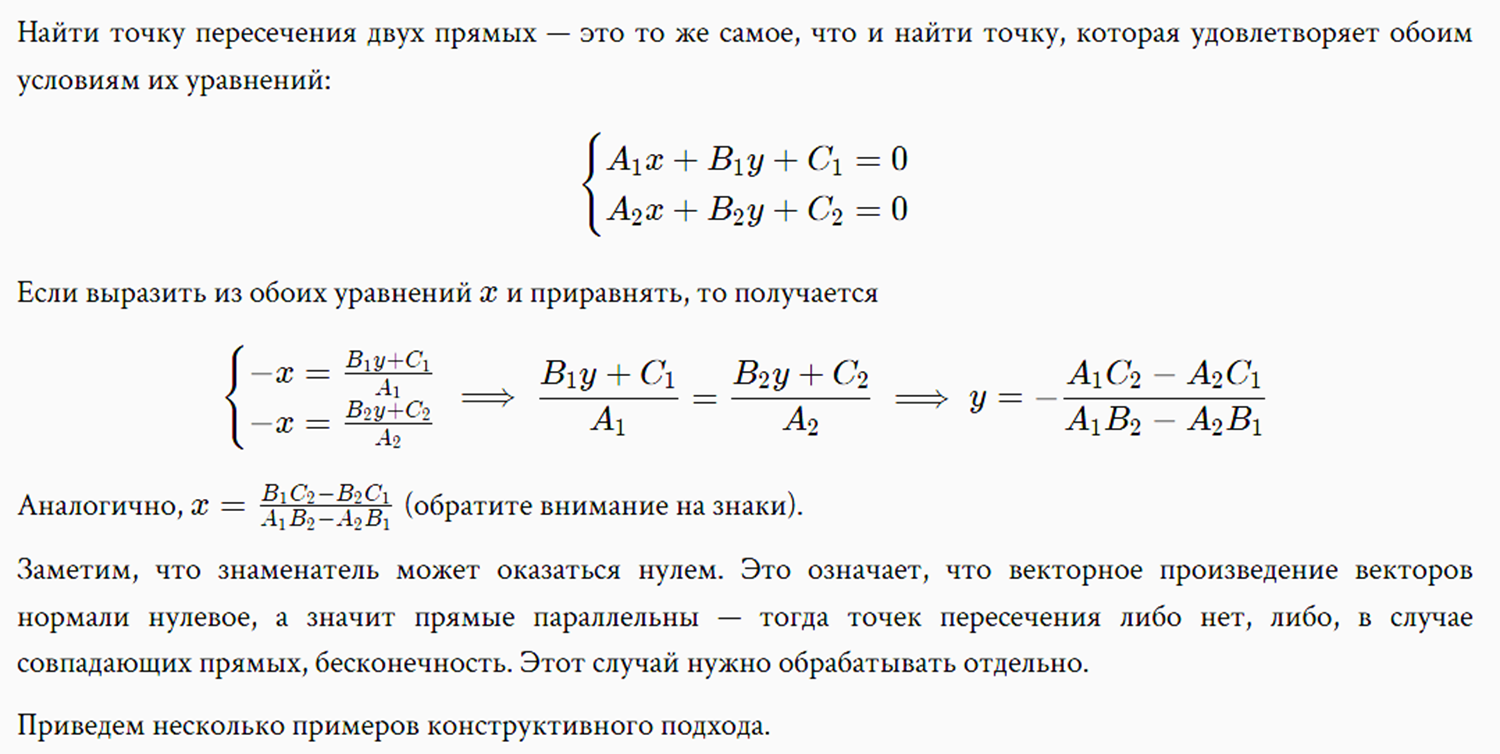

### Проекция точки на прямую
Чтобы спроецировать точку $P$ на прямую $L$, достаточно прибавить к ней нормальный вектор прямой, приведённый к длине $ρ(P,L)$ и направленный от точки к прямой. Поскольку нормальный вектор может быть направлен в двух разных (но противоположных друг другу!) направлениях, то достаточно попробовать оба варианта, и принять тот, в котором расстояние от получившейся точки до прямой будет меньше.

### Отражение от прямой

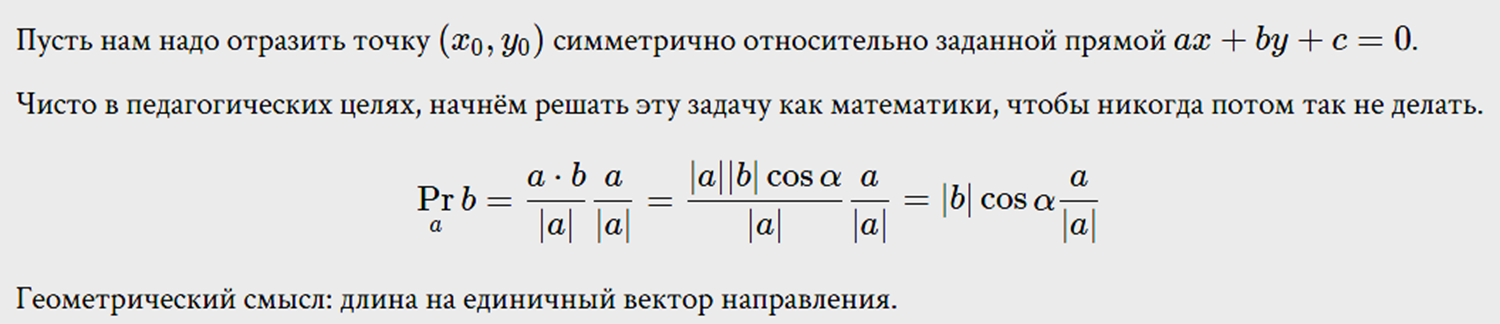

### Многоугольники

Многоугольник определяется как часть плоскости, ограниченная какой-то замкнутой ломаной.

Разные типы многоугольников
* Многоугольник называется простым, если граничная ломаная не имеет точек самопересечения. На картинке все многоугольники кроме последнего являются простыми.

* Многоугольник называется выпуклым, если для любых его двух точек, все точки на отрезке между ними тоже принадлежат многоугольнику. Первые два многоугольника являются выпуклыми.

* Выпуклый многоугольник называется правильным, если у него равны все стороны и все углы. Все правильные многоугольники также можно вписать в окружность, но обратное неверно.

В трёхмерном пространстве обобщением многоугольника является многогранник.

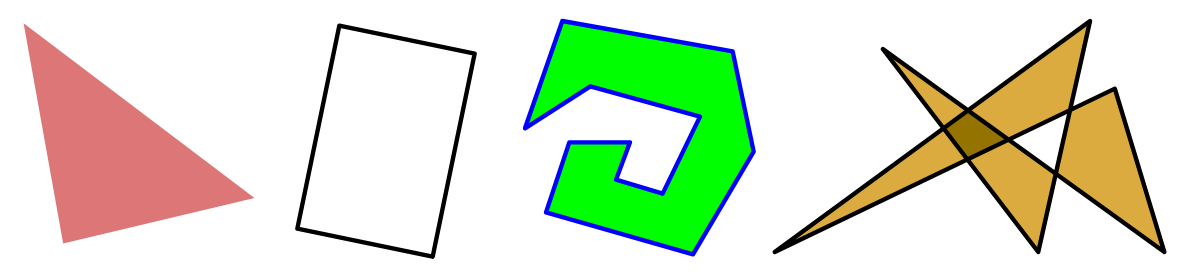

### Площади
В самом простом случае — для треугольника — площадь можно посчитать по готовым формулам через основание и высоту, а можно воспользоваться свойством векторного произведения:

$V = 1/2(B−A)×(C−A)$

В случае произвольного многоугольника, заданного последовательностью вершин в порядке обхода, можно поступить так: пройдемся по всем ребрам и для каждого добавим в сумму его ориентированную площадь треугольника, заданного этим ребром и началом координат.

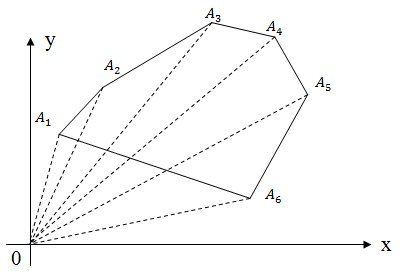

Все пары вершин, идущие по часовой стрелке, учтутся с отрицательным знаком, а против часовой — с положительным, и поэтому отменят лишнюю площадь.

Формула верна в случае любых многоугольников без самопересечений, даже невыпуклых. Чтобы убедиться в этом, попробуйте зафиксировать какую-нибудь точку на плоскости и проверить, сколько раз и с какими знаками она учтется в сумме.

Отметим, что знак итогового результата зависит от того, в каком порядке обходить многоугольник (чтобы про это не думать, можно взять его по модулю).

Также существует возможно более интуитивный, но и более громоздкий метод трапеций, где мы так же проходимся по всем ребрам и складываем ориентированные площади, но не треугольников относительно начала координат, а трапеций с основанием на оси
$x$, в котором «нижние» трапеции аналогично отменяют лишнюю площадь «верхних».



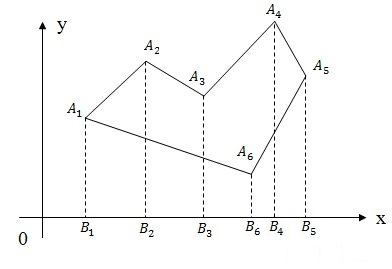

### Принадлежность точки


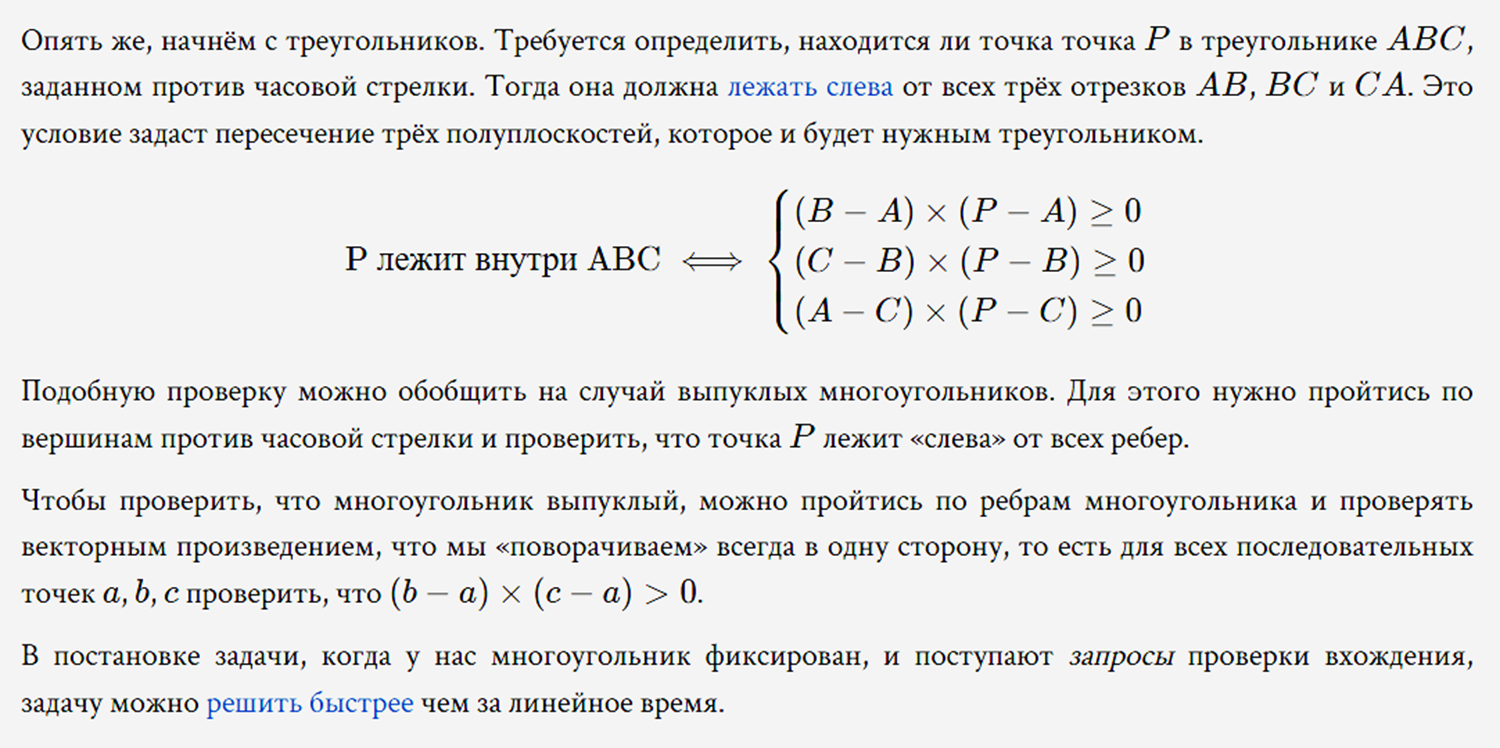

### Произвольный многоугольник
В более общем случае есть два популярных подхода, оба за $O(n)$.

Первый заключается в подсчете углов. Пройдемся по всем вершинам в порядке обхода и будем последовательно рассматривать углы с вершиной в точке $P$ и лучами, проходящими через соседние вершины многоугольника. Если просуммировать эти ориентированные углы, то получится какая-то величина $θ$. Если точка $P$ лежит внутри многоугольника, то $θ=±2π$, иначе $θ=0$.

Второй заключается в подсчете, сколько раз луч, выпущенный из $P$, пересекает ребра многоугольника.

Если из произвольной точки пустить любой луч, и если этот луч пересечет многоугольник, то он рано или поздно выйдет из этого многоугольника — потому что луч бесконечный, а многоугольник нет.

Если посчитать число пересечений с многоугольником, то для точки, находящейся внутри, это число будет нечетным («наружу-внутрь-наружу», 3 пересечения), в противном случае — четным.


Чтобы не обрабатывать отдельно случаи, когда луч пересекает вершину (сразу 2 ребра), его можно делать случайным — вероятность, что действительнозначное направление совпадет с конечным числом точек пренебрежимо мала.

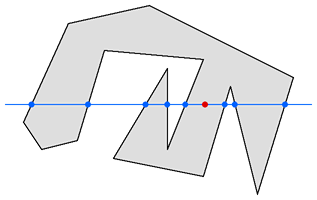

### Выпуклые оболочки
**Выпуклое множество** — такое множество точек, что, для любых двух точек множества, все точки на отрезке между ними тоже принадлежат этому множеству.

* Выпуклая оболочка множества точек — такое выпуклое множество точек, что все точки фигуры также лежат в нем.

* Минимальная выпуклая оболочка множества точек — это минимальная по площади выпуклая оболочка.

Для экономии времени дальше минимальные выпуклые оболочки мы будем называть просто выпуклыми оболочками.


Для практических целей выпуклые оболочки полезны тем, что они компактно хранят всю необходимую информацию о множестве точек, что позволяет быстро отвечать на разнообразные запросы на этом множестве.


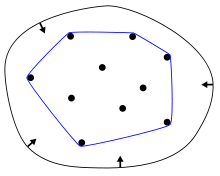

### Применения выпуклых оболочек

Перед тем, как научиться строить выпуклые оболочки, разберем несколько задач, которые можно решать с их помощью.

**Пара наиболее отдаленных точек**  
Дан набор $n$ точек, и требуется найти среди них пару наиболее отдаленных.

Заметим, что оптимальная пара гарантированно лежит на выпуклой оболочке этого множества: если бы одна из точек лежала строго внутри выпуклой оболочки, то можно было бы вместо неё выбрать какую-то более отдаленную.

Построим выпуклую оболочку всех точек и пронумеруем её вершины в порядке обхода против часовой стрелки. Заметим, что если для
$l$-той точки самой отдаленной была $r$-тая, то для $(l+1)$-ой и всех дальнейших никакая точка раньше $r$-той в обходе не может быть оптимальной.

Здесь возникает идея применить метод двух указателей: будем перебирать точку $l$ в оболочке и поддерживать оптимальную
$r$ для неё, в цикле while проверяя, лучше ли получатся ответ для пары $l$ и $(r+1)$. Так как суммарно $r$ сделает не более $O(n)$ увеличений, алгоритм будет работать за $O(n)$ плюс время построения выпуклой оболочки.

**Треугольник максимальной площади**  
Дан набор $n$ точек, и требуется найти среди них треугольник с максимальной площадью.

Аналогично предыдущей задаче, все три точки гарантированно будут на выпуклой оболочке, так что сразу построим её.

Теперь заметим, что для фиксированного основания $a$ и $b$, если мы увеличим его правую точку, то оптимальная третья точка $c$ будет иметь не меньший номер.

Значит, мы можем перебрать точку $a$, а затем с помощью метода двух указателей перебрать $b$, поддерживая оптимальный $c$. Суммарно алгоритм будет работать за $O(n^2)$.

## Алгоритм Джарвиса
Одним из самых простых алгоритмов построения выпуклой оболочки является алгоритм Джарвиса.

Выберем какую-нибудь точку $p_0$, которая гарантированно попадёт в выпуклую оболочку. Например, нижнюю, а если таких несколько, то самую левую из них.

Дальше будем действовать так: найдём самую «правую» точку от последней добавленной (то есть точку с минимальным полярным углом относительно неё) и добавим её в оболочку. Будем так итеративно добавлять точки, пока не «замкнёмся», то есть пока самой правой точкой не станет $p_0$.

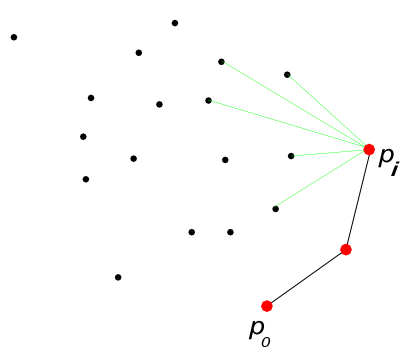

Корректность алгоритма легко доказывается по индукции:

* На нулевом шаге мы выбрали точку, точно лежащую в выпуклой оболочке.
* На $i$-м шаге мы взяли такую точку, что все остальные лежат по левую сторону отрезка ($p_{i−1},p_i$), и поэтому точно не перекрывают точку $p_i$.
Алгоритм Джарвиса также называют методом заворачивания подарка: мы как бы проходимся вокруг множества с оберткой, которая естественным образом заворачивается вокруг каждого следующего угла.

Для простоты, будем считать, что все точки различны, имеют целочисленные координаты, а также что нет трёх точек на одной прямой.

In [1]:
class Point:
    """Точка на плоскости с целыми координатами."""
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def __sub__(self, other):
        return Point(self.x - other.x, self.y - other.y)

    def cross(self, other):
        """Векторное произведение (псевдоскаляр)."""
        return self.x * other.y - self.y * other.x

    def __eq__(self, other):
        return self.x == other.x and self.y == other.y

    def __str__(self):
        return f"({self.x}, {self.y})"


def jarvis(points):
    """
    Алгоритм Джарвиса (метод заворачивания подарка).
    Возвращает список вершин выпуклой оболочки в порядке обхода против часовой стрелки.
    Предполагается:
      - все точки различны;
      - нет трёх коллинеарных точек на оболочке (для простоты);
      - координаты целые.
    """
    n = len(points)
    if n < 3:
        return points[:]  # оболочка из всех точек

    # 1. Находим самую нижнюю и левую точку (гарантированно в оболочке)
    p0 = points[0]
    for p in points:
        if p.y < p0.y or (p.y == p0.y and p.x < p0.x):
            p0 = p

    hull = []
    current = p0

    while True:
        hull.append(current)
        # Ищем следующую точку: она должна иметь максимальный полярный угол
        # относительно текущей (т.е. все остальные точки лежат "левее" от вектора current->next).
        next_point = points[0]  # временный кандидат
        for p in points:
            if p == current:
                continue
            # Если next_point ещё не задан, берём первый попавшийся
            if next_point == current:
                next_point = p
                continue
            # Векторное произведение (current->p) x (current->next_point)
            # Если оно > 0, значит p левее текущего кандидата -> выбираем p
            if (p - current).cross(next_point - current) > 0:
                next_point = p
        # Проверяем, замкнули ли оболочку
        if next_point == p0:
            break
        current = next_point

    return hull


# ========== Пример использования ==========
if __name__ == "__main__":
    pts = [Point(0, 3), Point(1, 2), Point(2, 1), Point(3, 0),
           Point(2, -1), Point(1, -2), Point(0, -3),
           Point(-1, -2), Point(-2, -1), Point(-3, 0),
           Point(-2, 1), Point(-1, 2)]

    hull = jarvis(pts)
    print("Выпуклая оболочка:")
    for p in hull:
        print(p)

Выпуклая оболочка:
(0, -3)
(3, 0)
(0, 3)
(-3, 0)


Для каждой точки выпуклой оболочки (обозначим их количество за
$h$) мы из всех оставшихся $O(n)$ точек будем искать оптимальную, что суммарно будет работать за $O(nh)$.

Важно помнить, что асимптотика именно $O(nh)$, а не $O(n^2)$: существуют задачи, где оболочка маленькая, и это существенно.


## Алгоритм Грэхэма

Алгоритм Грэхэма — это оптимизация алгоритма Джарвиса, основанная на следующем наблюдении: если отсортировать все точки по полярному углу относительно точки $p_0$, то выпуклая оболочка будет какой-то подпоследовательностью такого отсортированного массива точек.

Алгоритм последовательно строит выпуклые оболочки для каждого префикса этого отсортированного массива. Можно заметить, что при добавлении $i$-й точки в оболочку нужно лишь удалить сколько-то последних добавленных точек, которые не будут входить в новую оболочку, а именно тех, которые «покрываются» новой точкой и своей предыдущей.

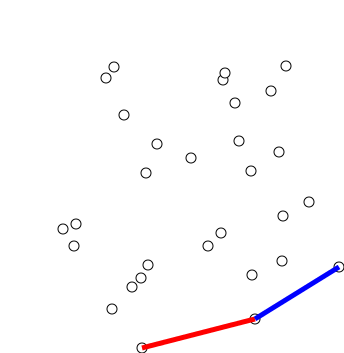

https://ru.algorithmica.org/cs/convex-hulls/graham/

Чтобы проводить это удаление эффективно, мы можем хранить выпуклую оболочку в стеке и в цикле while смотреть на три последние точки и проверять, образуют ли они правый поворот. Если это так, то среднюю следует удалить — мы нашли треугольник ($p_0,p_i,p_{i−2}$), который содержит $p_{i−1}$, а значит её можно удалить.

Каждая точка будет добавлена один раз удалена не более одного раза, что занимает константное количество операций. Соответственно, время работы будет упираться во время работы сортировки, то есть $O(nlogn)$.

In [1]:
import math
from functools import cmp_to_key

class Point:
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def __sub__(self, other):
        return Point(self.x - other.x, self.y - other.y)

    def cross(self, other):
        """Векторное произведение (псевдоскаляр)."""
        return self.x * other.y - self.y * other.x

    def __eq__(self, other):
        return self.x == other.x and self.y == other.y

    def __str__(self):
        return f"({self.x}, {self.y})"


def graham(points):
    """
    Алгоритм Грэхема построения выпуклой оболочки.
    Возвращает список вершин в порядке обхода против часовой стрелки.
    """
    n = len(points)
    if n < 3:
        return points[:]

    # 1. Находим p0: самую нижнюю, при равенстве – самую левую
    p0 = points[0]
    for p in points[1:]:
        if p.y < p0.y or (p.y == p0.y and p.x < p0.x):
            p0 = p

    # 2. Сортируем точки по полярному углу относительно p0
    def polar_cmp(a, b):
        # Векторное произведение (a-p0) x (b-p0) > 0 => a левее b
        cross = (a - p0).cross(b - p0)
        if cross != 0:
            return -1 if cross > 0 else 1   # убывание: больший угол идёт раньше
        # Если коллинеарны – ближе к p0 идёт первой
        da = (a.x - p0.x)**2 + (a.y - p0.y)**2
        db = (b.x - p0.x)**2 + (b.y - p0.y)**2
        return -1 if da < db else 1

    sorted_points = sorted(points, key=cmp_to_key(polar_cmp))

    # 3. Строим оболочку в стеке
    hull = []
    for p in sorted_points:
        # Пока в стеке >=2 точек и новый вектор образует правый поворот (cross <= 0) – удаляем последнюю
        while len(hull) >= 2:
            a = hull[-2]
            b = hull[-1]
            # Векторы: b->p и a->b
            if (b - a).cross(p - b) <= 0:
                hull.pop()
            else:
                break
        hull.append(p)

    return hull


# ========== Пример использования ==========
if __name__ == "__main__":
    pts = [Point(0, 3), Point(1, 2), Point(2, 1), Point(3, 0),
           Point(2, -1), Point(1, -2), Point(0, -3),
           Point(-1, -2), Point(-2, -1), Point(-3, 0),
           Point(-2, 1), Point(-1, 2)]

    hull = graham(pts)
    print("Выпуклая оболочка (Грэхем):")
    for p in hull:
        print(p)

Выпуклая оболочка (Грэхем):
(0, -3)
(3, 0)
(0, 3)
(-3, 0)


Сортировка – $O(n log n)$, построение оболочки – $O(n)$.

Итоговая сложность – $O(n log n)$, что значительно быстрее алгоритма Джарвиса ($O(nh)$) для больших $n$.

## Алгоритм Чана
Как уже упоминалось ранее, иногда существенную роль играет то, что алгоритм Джарвиса работает за $O(nh)$, а не $O(n^2)$: когда известно, что оболочка небольшая, он лучше алгоритма Грэхэма за
$O(nlogn)$.

Алгоритм Чана пытается получить лучшее из двух и объединить алгоритмы Джарвиса и Грэхэма, чтобы получить асимптотику $O(nlogh)$.

**Алгоритм**. Разделим все точки на группы по $m$ точек. В каждой группе построим выпуклую оболочку за $O(mlogm)$ алгоритмом Грэхэма. Точки никак не упорядочены, и эти оболочки могут пересекаться — это нормально. Суммарно для всех групп понадобится
$O(nlogm)$ операций.

Затем, начиная с самой левой нижней точки, мы будем строить общую выпуклую оболочку аналогично алгоритму Джарвиса, но теперь «самую правую точку» можно находить каждый раз не за $O(n)$, а за
$O(\frac{n}{m}logm)$, если делать бинарный поиск в каждой из
$\frac{n}{m}$ оболочек.

Получается, что такое решение будет работать за $O(h
\frac{n}{m}logm+nlogm)$. Если заранее приблизительно знать $h$, то можно положить $m=h$, и тогда асимптотика составит $O(nlogh)$.

Понятно, что ни при каких применимых на практике ограничениях, даже если оболочка состоит из трёх точек, этот алгоритм не будет быстрее обычного алгоритма Грэхэма, так что автор не будет приводить его реализацию. Этот способ просто интересен с теоретической точки зрения.

https://ru.algorithmica.org/cs/convex-hulls/chan/

# Библиотеки
https://docs.sympy.org/latest/modules/geometry/index.html

ИЛИ:

(!) scipy.spatial — это фундаментальный и незаменимый модуль в экосистеме SciPy для решения широкого круга задач вычислительной геометрии. Он сочетает в себе высокую производительность (благодаря использованию проверенных библиотек на C/C++), удобный Python API и бесшовную интеграцию с numpy


Модуль предоставляет инструменты для решения трех основных классов задач.

1. Построение пространственных структур данных (scipy.spatial)
Это основа модуля, которая позволяет разбивать пространство на области и находить базовые геометрические формы.

**Триангуляция Делоне** (scipy.spatial.Delaunay): Строит триангуляцию для множества точек. Она гарантирует, что ни одна из точек не попадет внутрь окружности, описанной вокруг любого из получившихся треугольников, что автоматически создает "хорошие", вытянутые треугольники. Триангуляция является основой для многих других алгоритмов.

In [4]:
from scipy.spatial import Delaunay
import numpy as np
points = np.array([[0, 0], [0, 1.1], [1, 0], [1, 1]])
tri = Delaunay(points) # Вычисляем триангуляцию
# tri.simplices содержит индексы точек для каждого треугольника[reference:2]
# tri.neighbors показывает соседей для каждого треугольника[reference:3]

* **Выпуклая оболочка** (scipy.spatial.ConvexHull): Находит наименьший выпуклый многоугольник (или многогранник), который охватывает все заданные точки. Это ключевая операция для анализа формы облака точек.

In [5]:
from scipy.spatial import ConvexHull
hull = ConvexHull(points) # Вычисляем выпуклую оболочку
# hull.simplices содержит индексы точек, образующих грани оболочки

* **Диаграмма Вороного** (scipy.spatial.Voronoi): Разбивает плоскость на области ("ячейки") вокруг каждой заданной точки. Ячейка содержит все точки плоскости, которые находятся ближе к своей "базовой" точке, чем к любой другой.

In [6]:
from scipy.spatial import Voronoi, voronoi_plot_2d
vor = Voronoi(points) # Вычисляем диаграмму Вороного
# vor.vertices — это координаты вершин (углов) этой диаграммы[reference:8]

2. **Быстрый поиск ближайших соседей** (KDTree и cKDTree)
Этот класс реализует структуру данных k‑d дерево, которая позволяет очень быстро отвечать на вопросы типа: "Какая точка из набора ближе всего к заданной точке P?".

Производительность: k‑d дерево радикально ускоряет поиск, особенно когда у вас есть статический набор данных и множество запросов.

cKDTree vs KDTree: Ранее класс cKDTree (где "c" означало "C implementation") был значительно быстрее. Начиная с SciPy версии 1.6.0, они стали функционально и по производительности идентичны, а cKDTree оставлен только для обратной совместимости. В новом коде рекомендуется использовать KDTree.

3. **Вычисление расстояний** (scipy.spatial.distance)
Этот дочерний модуль — ваш главный инструмент для работы с метриками и матрицами расстояний. Он содержит десятки функций для различных метрик: от классических Евклидовой, Манхэттенской до специализированных, например, для булевых векторов (Jaccard, Hamming и др.).

* pdist (pairwise distances): Вычисляет попарные расстояния между всеми точками в одном наборе данных, возвращая "сжатый" массив.

* cdist (cross distances): Вычисляет расстояния между каждой точкой из одного набора и каждой точкой из другого, возвращая матрицу расстояний.

* squareform: Преобразует "сжатый" массив в полную квадратную матрицу расстояний и обратно.

Совет: При работе с большими объемами данных избегайте поэлементного вычисления расстояний в цикле for. Используйте векторизованные функции pdist или cdist — это будет на много порядков быстрее.

4. **Трехмерные вращения** (scipy.spatial.transform)
Этот подмодуль предоставляет современный и гибкий интерфейс для работы с поворотами в трехмерном пространстве.

* Класс Rotation: Позволяет создавать вращения и конвертировать их между всеми популярными представлениями: матрицами поворота, кватернионами, векторами вращения (Родрига), углами Эйлера и т.д..

* Slerp: Класс для выполнения сферической линейной интерполяции (Spherical Linear Interpolation) между двумя вращениями.

In [7]:
from scipy.spatial.transform import Rotation as R
# Создаем вращение на 45 градусов вокруг оси Z из вектора вращения
r = R.from_rotvec(np.pi/4 * np.array([0, 0, 1]))

* **Сильная сторона**: 2D-геометрия: Модуль наиболее оптимизирован и удобен для работы в двухмерном пространстве.

* **Слабая сторона**: 3D и выше: Хотя ключевые алгоритмы (Delaunay, ConvexHull, Voronoi) работают в любом количестве измерений, их визуализация и интерпретация результатов становятся сложной задачей.

* Вычислительная база: Все основные алгоритмы полагаются на библиотеку Qhull. Это мощное, но не всесильное решение. На некоторых коллинеарных или вырожденных наборах точек Qhull может выдавать ошибку. В таких случаях может потребоваться сглаживание входных данных (например, добавление небольшого шума) или настройка параметров, передаваемых в qhull_options.

* Точность вычислений: Модуль использует числа с плавающей точкой двойной точности (double). Если ваша задача требует абсолютной точности и избежания ошибок округления (например, в алгоритмах, где критично точное сравнение), scipy.spatial может не подойти.

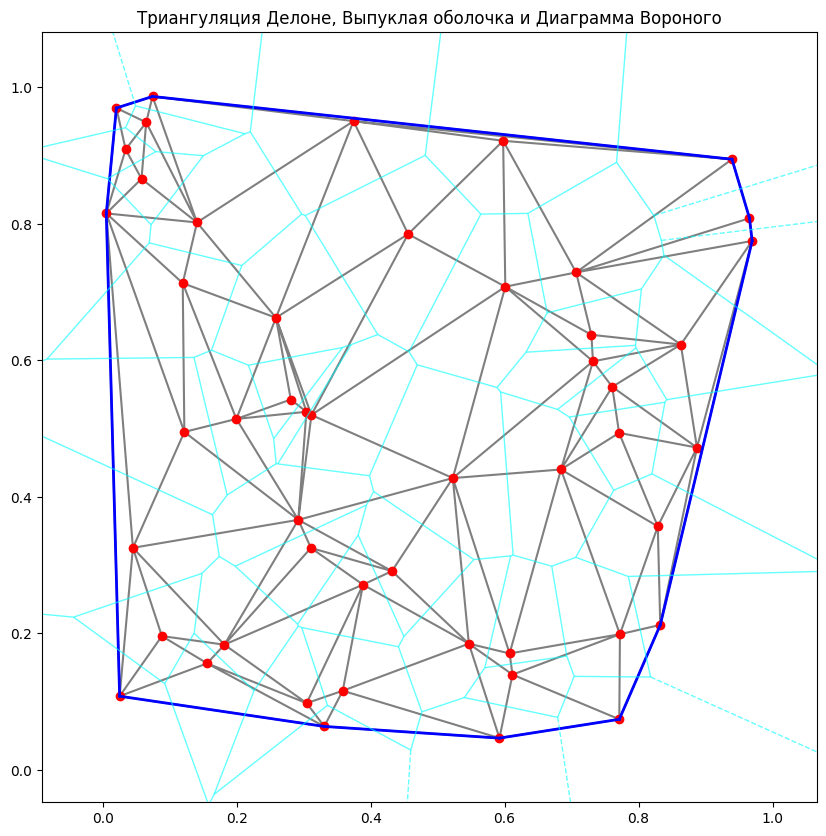

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import Delaunay, ConvexHull, Voronoi, voronoi_plot_2d

# 1. Генерируем случайные точки
np.random.seed(42)
points = np.random.rand(50, 2) # 50 случайных точек в 2D

# 2. Строим триангуляцию Делоне, выпуклую оболочку и диаграмму Вороного[reference:24][reference:25][reference:26]
tri = Delaunay(points)
hull = ConvexHull(points)
vor = Voronoi(points)

# 3. Визуализируем всё вместе для наглядности
plt.figure(figsize=(10, 10))
plt.triplot(points[:,0], points[:,1], tri.simplices, color='black', alpha=0.5, label='Триангуляция Делоне')
for simplex in hull.simplices:
    plt.plot(points[simplex, 0], points[simplex, 1], 'b-', linewidth=2, label='Выпуклая оболочка')
plt.scatter(points[:,0], points[:,1], color='red', label='Точки')
voronoi_plot_2d(vor, ax=plt.gca(), show_vertices=False, line_colors='cyan', line_width=1, line_alpha=0.6, point_size=0)
plt.title("Триангуляция Делоне, Выпуклая оболочка и Диаграмма Вороного")
#plt.legend()
#plt.axis('equal')
plt.show()